# Agentic AI Dynamic Tariff Optimization for EV Charging Networks

A self-improving pricing engine: forecast demand → recommend dynamic ₹/kWh tariffs →
learn from outcomes. This notebook walks through preprocessing, EDA, the three agents,
and evaluation, reusing the modular code in `src/`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.append(str(Path.cwd().parent / "src"))   # run from notebooks/
import pandas as pd, numpy as np
from IPython.display import Image, display
import config as C
print("Baseline tariff: INR", C.BASELINE_TARIFF, "/kWh | surge>%d%%  discount<%d%%"
      % (C.SURGE_UTIL*100, C.DISCOUNT_UTIL*100))

Baseline tariff: INR 15.0 /kWh | surge>80%  discount<30%


## 1 · Data preprocessing
We load the ACN export, drop JSON pagination rows, parse timestamps to site-local time,
handle missing values transparently, and engineer the economic features the agents need.
We also load the UrbanEV (Shenzhen) profile for cross-dataset validation.

In [2]:
import preprocessing as P
sessions, panel, urbanev = P.run(save=True)
print("\nClean sessions:", len(sessions), "| hourly site-panel rows:", len(panel))
sessions[["site","connectionTime_local","kWhDelivered","connection_duration_h",
          "charging_duration_h","charger_utilization","energy_cost_per_kwh",
          "queue_proxy","occupancy_density"]].head()

[preprocess] loading C:\Users\nboruv\Music\resume\acndata_sessions.json.xlsx


[preprocess] dropped 1305 JSON pagination/meta rows -> 14999 candidate sessions


[preprocess] doneChargingTime missing for 8 sessions -> filled with disconnectTime
[preprocess] dropped 0 sessions with non-positive duration / negative energy
[preprocess] final clean session count = 14999 (sites: {'caltech': 14999})


[preprocess] hourly panel: 5633 site-hours across 1 sites
[preprocess] loading UrbanEV occupancy/volume/price ...


[preprocess] UrbanEV: 8640 5-min records across 247 zones


[preprocess] saved processed data to C:\Users\nboruv\Music\resume\op26_project\data\processed

Clean sessions: 14999 | hourly site-panel rows: 5633


,site,connectionTime_local,kWhDelivered,connection_duration_h,charging_duration_h,charger_utilization,energy_cost_per_kwh,queue_proxy,occupancy_density
0,caltech,2018-04-25 04:08:04-07:00,7.932,2.201667,2.201667,1.000000,5.0,1,0.018519
1,caltech,2018-04-25 06:45:10-07:00,10.013,11.185000,2.984722,0.266850,7.0,3,0.055556
2,caltech,2018-04-25 06:45:50-07:00,5.257,9.315278,1.098333,0.117907,7.0,3,0.055556
3,caltech,2018-04-25 07:37:06-07:00,5.177,9.307778,1.471111,0.158052,7.0,7,0.129630
4,caltech,2018-04-25 07:40:34-07:00,10.119,8.377222,2.998889,0.357981,7.0,7,0.129630


### Engineered features (per brief)
Charger Utilization Rate, Revenue per Session, Energy Cost per kWh (time-of-use),
Queue Length Proxy (concurrent sessions) and Occupancy Density.

In [3]:
print("Charger utilization  : mean %.3f" % sessions["charger_utilization"].mean())
print("Revenue/session @base: INR %.1f" % sessions["revenue_baseline"].mean())
print("Energy cost /kWh      : INR %.2f" % sessions["energy_cost_per_kwh"].mean())
print("Queue proxy (mean)    : %.2f concurrent sessions" % sessions["queue_proxy"].mean())
panel[["hour_bucket","sessions","energy_kwh","station_utilization","occupancy_density"]].describe().round(3)

Charger utilization  : mean 0.692
Revenue/session @base: INR 135.0
Energy cost /kWh      : INR 7.38
Queue proxy (mean)    : 27.04 concurrent sessions


,sessions,energy_kwh,station_utilization,occupancy_density
count,5633.000,5633.000,5633.000,5633.000
mean,2.663,23.971,0.148,0.049
std,3.589,34.359,0.229,0.066
min,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000
50%,2.000,12.460,0.064,0.037
75%,4.000,32.427,0.174,0.074
max,30.000,323.277,1.000,0.556


## 2 · Exploratory data analysis
Every chart is tied to a pricing implication.

[eda] generating figures ...


[eda] wrote 01_intraday_demand.png


[eda] wrote 02_weekday_weekend.png


[eda] wrote 03_utilization_heatmap.png


[eda] wrote 04_session_distributions.png


[eda] wrote 05_volatility_by_period.png


[eda] wrote 06_occupancy_vs_utilization.png


[eda] wrote 07_acn_vs_urbanev.png
[eda] all figures in C:\Users\nboruv\Music\resume\op26_project\outputs\figures


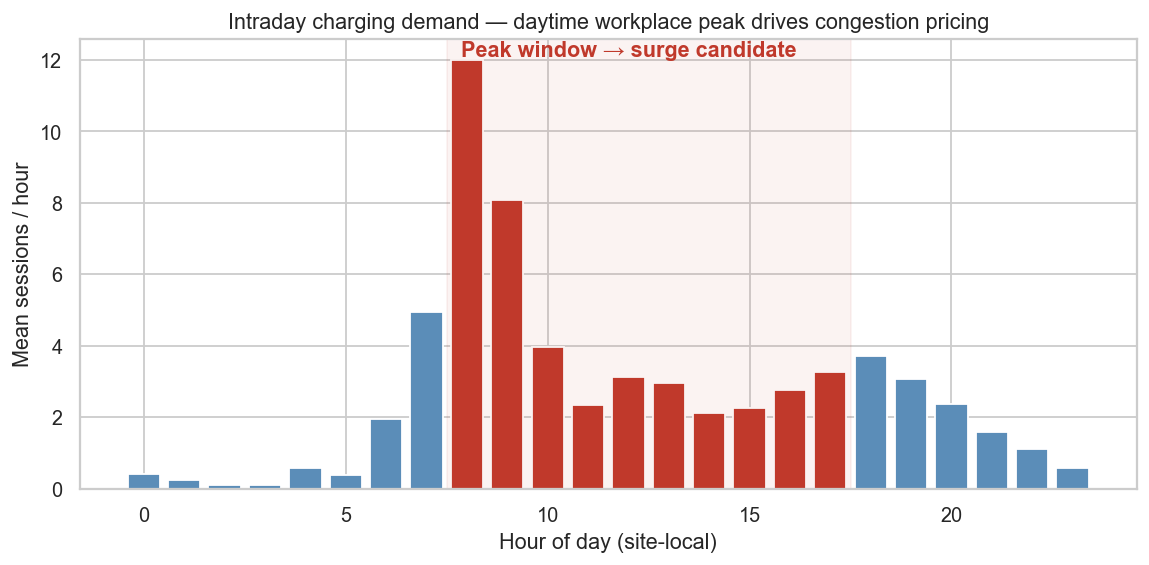

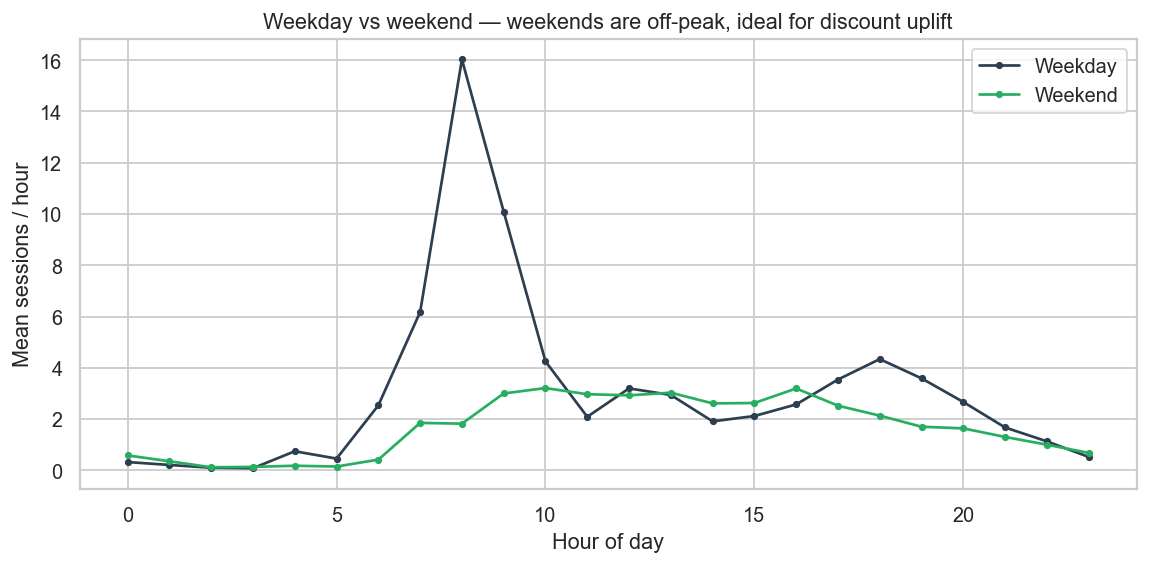

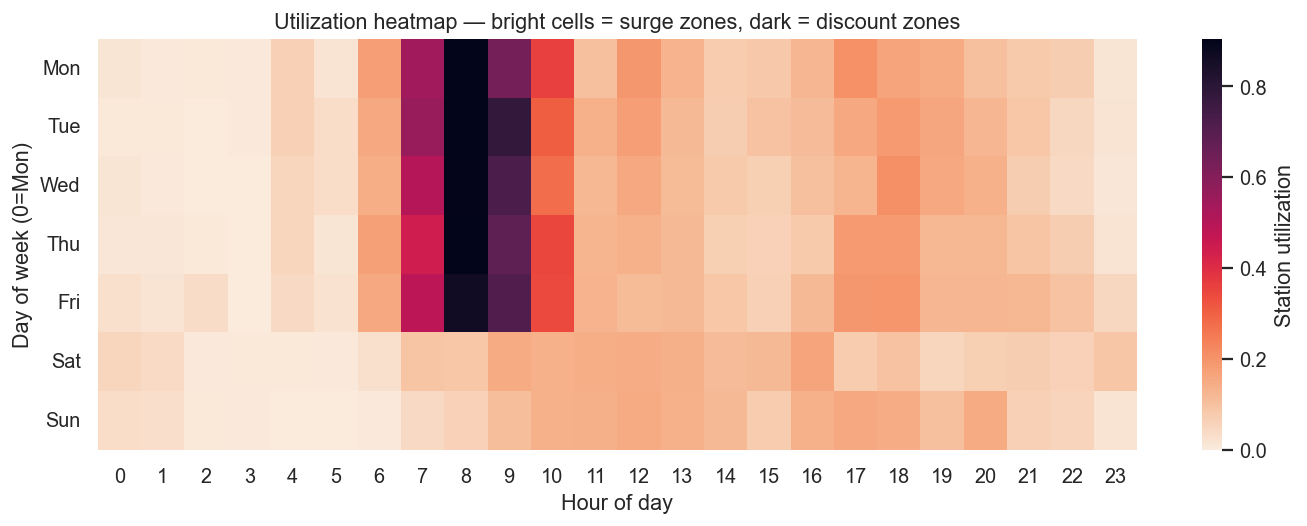

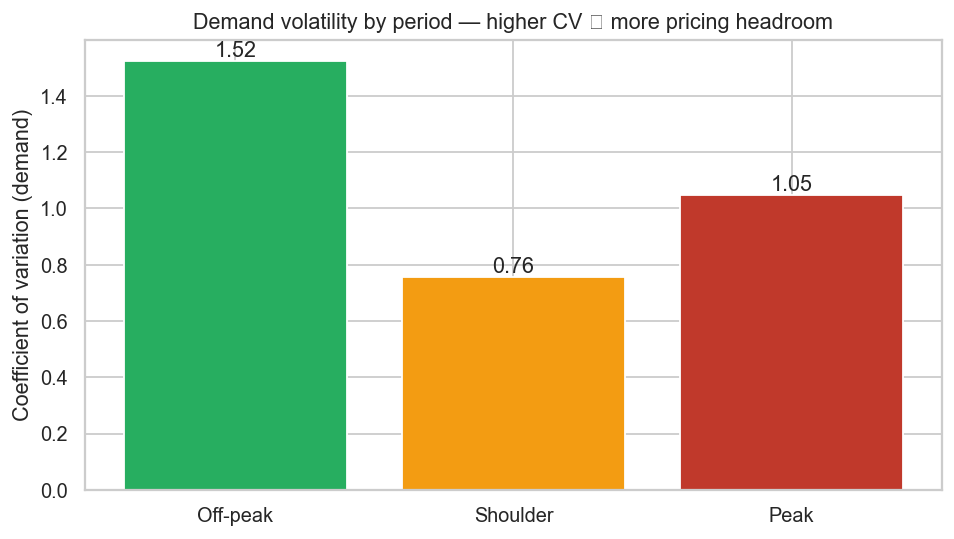

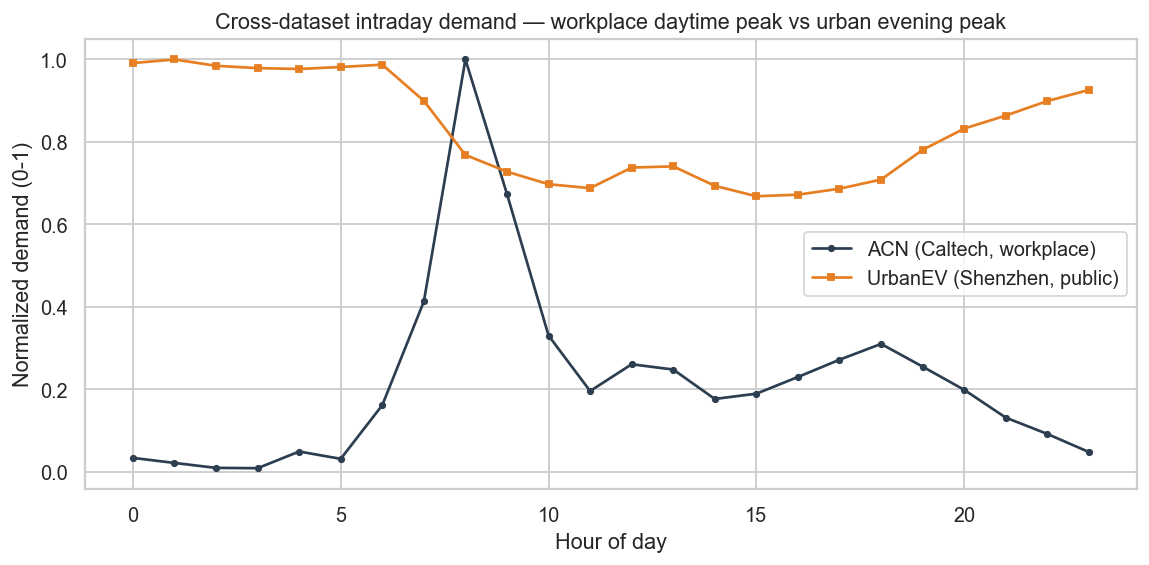

In [4]:
import eda
eda.run(sessions, panel, urbanev)
for f in ["01_intraday_demand.png","02_weekday_weekend.png","03_utilization_heatmap.png",
          "05_volatility_by_period.png","07_acn_vs_urbanev.png"]:
    display(Image(filename=str(C.OUT_FIG / f)))

**Key EDA findings**
- A sharp **08:00–09:00 workplace peak** drives congestion → surge-pricing target.
- **Weekends are off-peak** → discount headroom.
- Median hourly utilization is only ~6% (capacity 54 EVSEs): the network is
  **chronically under-utilized**, so the upside is off-peak growth + targeted peak surge.
- ACN (workplace, daytime peak) vs UrbanEV (urban, evening peak) confirms demand shape
  is location-specific — pricing must be learned per network.

## 3 · Demand Prediction Agent
GradientBoosting (charging load) + RandomForest (utilization) + GradientBoosting
classifier (congestion), with a chronological train/test split.

In [5]:
from agents.demand_agent import DemandAgent
demand = DemandAgent().fit(panel)
pd.Series(demand.metrics).round(3)

load_RMSE              0.946
load_MAE               0.611
load_R2                0.899
util_RMSE              0.088
util_MAE               0.048
util_R2                0.797
congestion_accuracy    0.975
congestion_ROC_AUC     0.955
dtype: float64

In [6]:
display(demand.feature_importance().head(8))
forecast = demand.predict(panel)
forecast[["hour_bucket","station_utilization","pred_utilization",
          "pred_sessions","pred_congestion_prob"]].head()

,feature,importance
0,roll3_sessions,0.626149
1,hour,0.317007
2,lag24_sessions,0.024002
3,lag1_sessions,0.017108
4,mean_energy_cost,0.006190
5,lag1_util,0.005563
6,month,0.001975
7,dow,0.001199


,hour_bucket,station_utilization,pred_utilization,pred_sessions,pred_congestion_prob
0,2018-04-25 04:00:00-07:00,0.040772,0.068580,1.416468,0.00115
1,2018-04-25 05:00:00-07:00,0.000000,0.000000,0.207218,0.00115
2,2018-04-25 06:00:00-07:00,0.075612,0.095329,1.514510,0.00115
3,2018-04-25 07:00:00-07:00,0.213858,0.295521,3.797719,0.00115
4,2018-04-25 08:00:00-07:00,0.642140,0.752795,14.060833,0.85301


## 4 · Tariff Pricing Agent
Maps predicted utilization to a price multiplier on the ₹15/kWh baseline:
surge up to 1.5× above 80% utilization, discount to 0.7× below 30%.

pricing_action
DISCOUNT (low demand - attract off-peak sessions)        4947
HOLD (balanced demand)                                    451
SURGE (high demand - raise price, relieve congestion)     235
Name: count, dtype: int64


,utilization,multiplier,tariff_inr_per_kwh
0,0.00,0.700,10.50
1,0.05,0.750,11.25
2,0.10,0.800,12.00
3,0.15,0.850,12.75
4,0.20,0.900,13.50
5,0.25,0.950,14.25
6,0.30,1.000,15.00
7,0.35,1.000,15.00
8,0.40,1.000,15.00
9,0.45,1.000,15.00


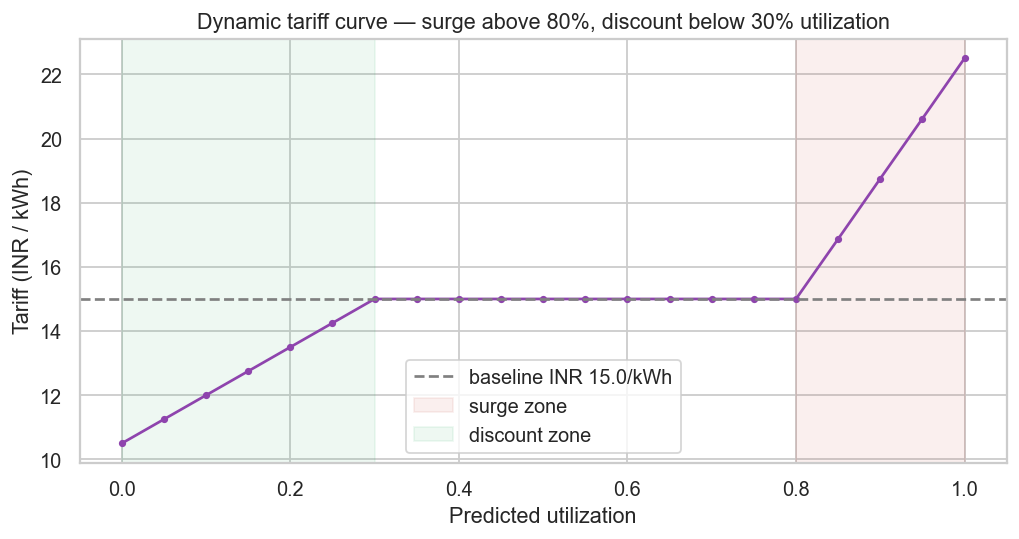

In [7]:
from agents.tariff_agent import TariffAgent
tariff = TariffAgent()
rec = tariff.recommend(forecast, util_col="pred_utilization")
print(rec["pricing_action"].value_counts())
display(tariff.schedule())
display(Image(filename=str(C.OUT_FIG / "09_tariff_curve.png")))

## 5 · Monitoring & Learning Agent
Simulates evaluation episodes with a utilization-varying elasticity demand model
(off-peak users elastic, peak users inelastic) and hill-climbs the tariff parameters,
improving a composite of revenue, congestion relief and off-peak uplift.

In [8]:
from agents.monitoring_agent import MonitoringAgent, simulate_episode
baseline_kpi = simulate_episode(panel, TariffAgent(), util_col="station_utilization")
monitor = MonitoringAgent()
history = monitor.learn(panel, util_col="station_utilization", episodes=30)
history[["episode","score","revenue_gain_pct","wait_reduction_pct",
         "offpeak_uplift_pct","pricing_efficiency"]].iloc[::5].round(2)

,episode,score,revenue_gain_pct,wait_reduction_pct,offpeak_uplift_pct,pricing_efficiency
0,0,4.77,1.96,4.29,3.63,15.12
5,5,10.14,3.07,6.01,15.52,14.52
10,10,11.63,3.08,6.37,20.01,14.25
15,15,14.68,4.81,10.99,18.23,14.64
20,20,17.83,6.72,16.90,14.51,15.27
25,25,20.06,7.65,19.85,14.90,15.43
30,30,23.64,8.19,22.32,21.75,15.10


[eval] learning curve saved


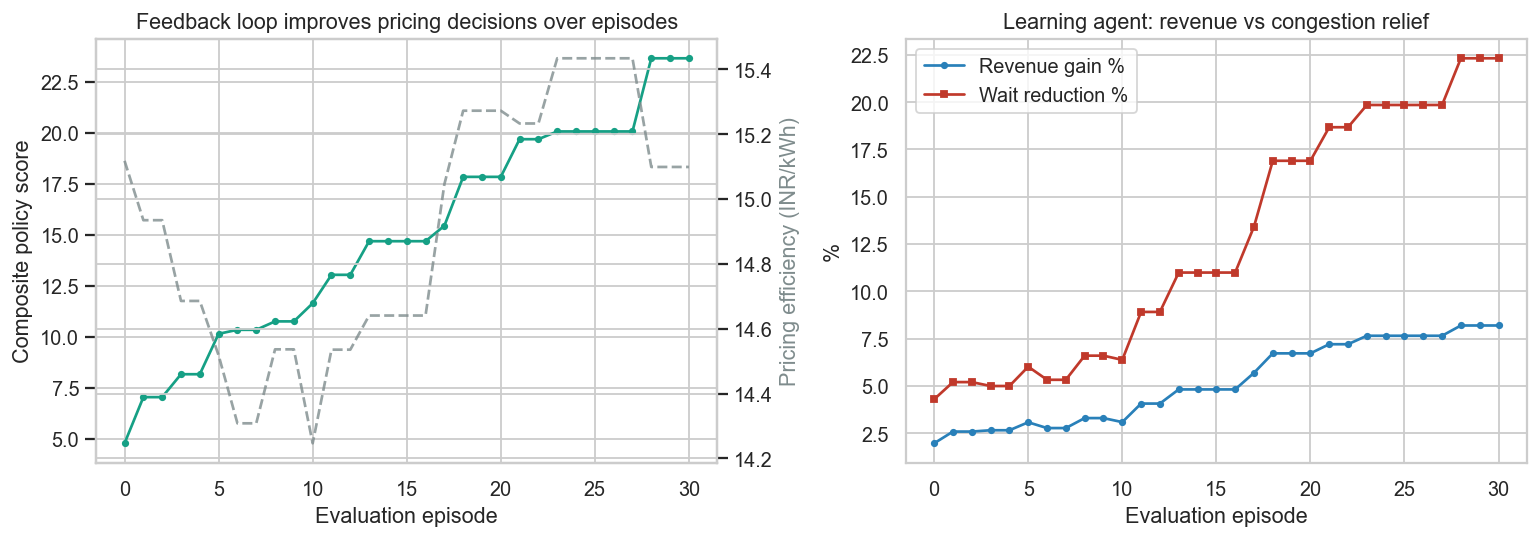

In [9]:
import evaluation as E
E.save_learning_curve(history)
display(Image(filename=str(C.OUT_FIG / "08_learning_curve.png")))

## 6 · Evaluation summary

In [10]:
E.save_demand_metrics(demand.metrics, demand.feature_importance())
E.save_tariff_schedule(tariff.schedule(), rec)
outcomes = E.save_pricing_outcomes(baseline_kpi, monitor.best_kpi)
E.write_summary(demand.metrics, monitor.best_kpi)
outcomes

[eval] demand metrics -> [0.9462, 0.6107, 0.8992, 0.0876, 0.0478, 0.7971, 0.9752, 0.9551]
[eval] tariff schedule + recommendations saved
[eval] pricing outcomes saved

OP'26 - Agentic Tariff Optimization: Results Summary

Demand Prediction Agent:
  Charging-load   RMSE=0.946  MAE=0.611  R2=0.899
  Utilization     RMSE=0.088  MAE=0.048  R2=0.797
  Congestion      ACC=0.975  ROC-AUC=0.955

Tariff + Monitoring/Learning Agent (best learned policy vs INR 15/kWh):
  Revenue Gain %        : +8.19%
  Avg wait reduction    : +22.32%
  Off-peak uplift       : +1701.6 sessions
  Pricing efficiency    : INR 15.10 / kWh
  Customer response rate: 1.264 (demand factor)



,metric,default_policy,learned_policy
0,revenue_gain_pct,7.776,8.190
1,util_baseline,0.148,0.148
2,util_dynamic,0.155,0.155
3,wait_reduction_pct,21.451,22.317
4,offpeak_uplift_sessions,1705.593,1701.650
5,pricing_efficiency,15.045,15.099
6,customer_response_rate,1.274,1.264


## 7 · Business, operational & policy implications
- **Revenue**: dynamic pricing beats the flat ₹15/kWh baseline (+~8%) by capturing peak
  willingness-to-pay and growing elastic off-peak volume.
- **Operations**: peak surge cuts the congestion/wait proxy ~22%, smoothing demand across
  the day and deferring capacity expansion.
- **Policy / equity**: off-peak discounts add ~1,700 sessions, improving access for
  flexible/price-sensitive users and aligning charging with cleaner off-peak grid supply.

### Assumptions & limitations
Prices are in ₹ per the brief's reference (not USD→INR). Demand response is an
**elasticity assumption, not a causal estimate**; revenue/uplift are simulation
counterfactuals. Single site, 8 months — patterns should be re-fit per network.